# Modelagem de Sobrevida — LUSC

Este notebook realiza a modelagem de sobrevida para o subtipo LUSC.

A base usada aqui já foi tratada no notebook anterior de tratamento LUSC.

Modelos avaliados:
1. Cox Proportional Hazards
2. Weibull AFT
3. Random Survival Forest
4. Gradient Boosting Survival Analysis
5. DeepSurv
6. DeepHit

Métrica principal:
- C-index

A validação será feita com 5 folds, mantendo a proporção de eventos por meio do `StratifiedKFold`.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

from lifelines import CoxPHFitter, WeibullAFTFitter
from lifelines.utils import concordance_index

from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.metrics import concordance_index_censored

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

In [2]:
try:
    import torch
    import torchtuples as tt

    from pycox.models import CoxPH, DeepHitSingle
    from pycox.evaluation import EvalSurv

    DEEP_OK = True
    print("Bibliotecas de deep learning carregadas com sucesso.")

except Exception as e:
    DEEP_OK = False
    print("Não foi possível carregar pycox/torch.")
    print("Erro:", e)

Bibliotecas de deep learning carregadas com sucesso.


In [4]:
COHORT = "LUSC"

PROJECT_DIR = Path("..").resolve()

DATA_PATH = PROJECT_DIR / "data" / "processed" / "lusc" / "lusc_modeling_dataset.csv"

RESULTS_DIR = PROJECT_DIR / "reports" / "results" / "lusc"
FIGURES_DIR = PROJECT_DIR / "reports" / "figures" / "lusc"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TIME_COL = "surv__OS.time"
EVENT_COL = "surv__OS"

SEED = 42
N_SPLITS = 5

In [5]:
print("Carregando base final de modelagem LUSC...")
print(DATA_PATH)

df = pd.read_csv(DATA_PATH, sep=";")

print("Shape original:", df.shape)
display(df.head())

Carregando base final de modelagem LUSC...
/workspaces/An-lise-de-Sobrevida/data/processed/lusc/lusc_modeling_dataset.csv
Shape original: (494, 61)


,patient_id,surv__OS.time,surv__OS,clin__age_at_initial_pathologic_diagnosis,clin__number_pack_years_smoked,clin__tobacco_smoking_history,clin__age_at_initial_pathologic_diagnosis_missing,clin__number_pack_years_smoked_missing,clin__tobacco_smoking_history_missing,clin__gender_bin,clin__history_of_neoadjuvant_treatment_bin,clin__radiation_therapy_bin,clin__anatomic_neoplasm_subdivision_Bronchial,clin__anatomic_neoplasm_subdivision_L-Lower,clin__anatomic_neoplasm_subdivision_L-Upper,clin__anatomic_neoplasm_subdivision_Other (please specify),clin__anatomic_neoplasm_subdivision_R-Lower,clin__anatomic_neoplasm_subdivision_R-Middle,clin__anatomic_neoplasm_subdivision_R-Upper,clin__anatomic_neoplasm_subdivision_Unknown,clin__anatomic_neoplasm_subdivision_[Discrepancy],clin__histological_type_Lung Basaloid Squamous Cell Carcinoma,clin__histological_type_Lung Papillary Squamous Cell Caricnoma,clin__histological_type_Lung Small Cell Squamous Cell Carcinoma,clin__histological_type_Lung Squamous Cell Carcinoma- Not Otherwise Specified (NOS),clin__pathologic_stage_group_I,clin__pathologic_stage_group_II,clin__pathologic_stage_group_III,clin__pathologic_stage_group_IV,clin__pathologic_T_group_T1,clin__pathologic_T_group_T2,clin__pathologic_T_group_T3,clin__pathologic_T_group_T4,clin__pathologic_N_group_N0,clin__pathologic_N_group_N1,clin__pathologic_N_group_N2,clin__pathologic_N_group_N3,clin__pathologic_N_group_NX,clin__pathologic_M_group_M0,clin__pathologic_M_group_M1,clin__pathologic_M_group_MX,clin__residual_tumor_R0,clin__residual_tumor_R1,clin__residual_tumor_R2,clin__residual_tumor_RX,clin__residual_tumor_Unknown,ZFP42,ALDH7A1,HKDC1,NRTN,OTX2,GCGR,F13A1,ACVRL1,MDH1,SEMA3B,ZNF71,FGF4,GAGE2A,SLC39A8,SOX2
0,TCGA-18-3406,371.0,1,67.0,200.0,4.0,0,0,0,1,0.0,0.0,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,1.7494,8.6559,5.2778,2.8677,1.3645,4.0659,10.0489,9.0286,13.0819,4.7113,8.0951,0.0000,0.0000,10.4514,8.4698
1,TCGA-18-3407,136.0,1,72.0,40.0,3.0,0,0,0,1,0.0,0.0,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,0.0000,7.8593,6.1676,2.7461,0.9646,3.5193,8.2571,8.9985,12.0345,6.8297,5.6575,0.0000,3.9771,10.3928,12.2245
2,TCGA-18-3408,2304.0,1,77.0,30.0,4.0,0,0,0,0,0.0,0.0,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,0.0000,7.7650,5.0458,0.6719,1.4749,0.0000,11.7268,8.2709,12.4069,3.6172,5.5986,0.6719,0.0000,10.1578,13.3835
3,TCGA-18-3409,3747.0,0,74.0,20.0,3.0,0,0,0,1,0.0,0.0,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,1.3440,10.7186,3.4254,9.0350,1.8335,2.7314,10.7797,9.7230,11.6099,10.1626,7.9463,0.0000,0.0000,9.7864,5.2450
4,TCGA-18-3410,146.0,1,81.0,0.0,3.0,0,1,0,1,0.0,0.0,False,False,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,True,False,False,False,False,True,False,False,True,False,False,False,False,0.4791,10.3908,4.9875,3.6349,3.5404,1.1255,8.6900,10.2864,11.8564,4.2569,8.5270,0.0000,0.0000,9.5320,9.3927


In [6]:
print("Colunas de sobrevida:")
print(TIME_COL, "existe?", TIME_COL in df.columns)
print(EVENT_COL, "existe?", EVENT_COL in df.columns)

print("\nQuantidade de colunas:", df.shape[1])
print("Quantidade de pacientes:", df.shape[0])

Colunas de sobrevida:
surv__OS.time existe? True
surv__OS existe? True

Quantidade de colunas: 61
Quantidade de pacientes: 494


In [7]:
if "patient_id" in df.columns:
    patient_ids = df["patient_id"].copy()
    df = df.drop(columns=["patient_id"])
else:
    patient_ids = pd.Series(range(len(df)), name="patient_id")

print("Shape após remover patient_id:", df.shape)

Shape após remover patient_id: (494, 60)


In [8]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Total de nulos:", int(df.isna().sum().sum()))

nulos = df.isna().sum().sort_values(ascending=False)
display(nulos[nulos > 0].head(30))

Total de nulos: 0


Series([], dtype: int64)

In [9]:
# Não fazer dropna global, porque isso pode remover muitos pacientes.
# Vamos tratar nulos das features pela mediana.
# As colunas de sobrevida não podem ter nulos.

antes = len(df)

df = df.dropna(subset=[TIME_COL, EVENT_COL]).copy()

depois = len(df)

print("Removidos por nulo em tempo/evento:", antes - depois)

feature_cols_temp = [
    c for c in df.columns
    if c not in [TIME_COL, EVENT_COL]
]

for col in feature_cols_temp:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("Total de nulos após tratamento:", int(df.isna().sum().sum()))
print("Shape final:", df.shape)

Removidos por nulo em tempo/evento: 0
Total de nulos após tratamento: 0
Shape final: (494, 60)


In [10]:
df[EVENT_COL] = df[EVENT_COL].astype(int)
df[TIME_COL] = df[TIME_COL].astype(float)

print("Eventos:")
print(df[EVENT_COL].value_counts())

print("\nTaxa de eventos:", round(df[EVENT_COL].mean() * 100, 2), "%")

print("\nTempo de sobrevida:")
print("Mínimo:", df[TIME_COL].min())
print("Mediana:", df[TIME_COL].median())
print("Máximo:", df[TIME_COL].max())

Eventos:
surv__OS
0    282
1    212
Name: count, dtype: int64

Taxa de eventos: 42.91 %

Tempo de sobrevida:
Mínimo: 1.0
Mediana: 663.0
Máximo: 5287.0


In [11]:
feature_cols = [
    c for c in df.columns
    if c not in [TIME_COL, EVENT_COL]
]

# Garantia contra vazamento
feature_cols = [
    c for c in feature_cols
    if "vital_status" not in c.lower()
]

X = df[feature_cols].copy()
tempo = df[TIME_COL].copy()
evento = df[EVENT_COL].copy()

print("X:", X.shape)
print("tempo:", tempo.shape)
print("evento:", evento.shape)
print("Eventos:", evento.sum())

X: (494, 58)
tempo: (494,)
evento: (494,)
Eventos: 212


In [12]:
skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)

folds = list(skf.split(X, evento))

print("Quantidade de folds:", len(folds))

for i, (train_idx, test_idx) in enumerate(folds, start=1):
    print(
        f"Fold {i}:",
        "treino =", len(train_idx),
        "| teste =", len(test_idx),
        "| eventos teste =", int(evento.iloc[test_idx].sum())
    )

Quantidade de folds: 5
Fold 1: treino = 395 | teste = 99 | eventos teste = 43
Fold 2: treino = 395 | teste = 99 | eventos teste = 43
Fold 3: treino = 395 | teste = 99 | eventos teste = 42
Fold 4: treino = 395 | teste = 99 | eventos teste = 42
Fold 5: treino = 396 | teste = 98 | eventos teste = 42


## Pré-processamento dentro dos folds

A remoção de baixa variância, remoção de alta correlação e padronização precisam ser feitas dentro de cada fold.

Isso evita que informações do conjunto de teste influenciem o treino.

In [13]:
def tirar_baixa_variancia(X_train, X_test, threshold=0.01):
    seletor = VarianceThreshold(threshold=threshold)

    X_train_sel = seletor.fit_transform(X_train)
    X_test_sel = seletor.transform(X_test)

    colunas = X_train.columns[seletor.get_support()]

    X_train_sel = pd.DataFrame(X_train_sel, columns=colunas, index=X_train.index)
    X_test_sel = pd.DataFrame(X_test_sel, columns=colunas, index=X_test.index)

    return X_train_sel, X_test_sel

In [14]:
def tirar_colinearidade(X_train, X_test, limite=0.90):
    corr = X_train.corr().abs()

    matriz_superior = corr.where(
        np.triu(np.ones(corr.shape), k=1).astype(bool)
    )

    colunas_remover = [
        col for col in matriz_superior.columns
        if any(matriz_superior[col] > limite)
    ]

    X_train_ok = X_train.drop(columns=colunas_remover, errors="ignore")
    X_test_ok = X_test.drop(columns=colunas_remover, errors="ignore")

    return X_train_ok, X_test_ok, colunas_remover

In [15]:
def padronizar_dados(X_train, X_test):
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    X_train_scaled = pd.DataFrame(
        X_train_scaled,
        columns=X_train.columns,
        index=X_train.index
    )

    X_test_scaled = pd.DataFrame(
        X_test_scaled,
        columns=X_test.columns,
        index=X_test.index
    )

    return X_train_scaled, X_test_scaled

In [16]:
def preparar_fold(X_train, X_test, usar_scaler=True, var_threshold=0.01, corr_threshold=0.90):
    # 1. tirar baixa variância
    X_train_prep, X_test_prep = tirar_baixa_variancia(
        X_train,
        X_test,
        threshold=var_threshold
    )

    # 2. tirar colunas muito correlacionadas
    X_train_prep, X_test_prep, removidas_corr = tirar_colinearidade(
        X_train_prep,
        X_test_prep,
        limite=corr_threshold
    )

    # 3. padronizar, se precisar
    if usar_scaler:
        X_train_prep, X_test_prep = padronizar_dados(
            X_train_prep,
            X_test_prep
        )

    return X_train_prep, X_test_prep, removidas_corr

In [17]:
def criar_y_sksurv(tempo_parte, evento_parte):
    return Surv.from_arrays(
        event=evento_parte.astype(bool).values,
        time=tempo_parte.astype(float).values
    )

In [18]:
resultados_folds = []
resumo_modelos = []

def guardar_resultado(modelo, fold, c_train, c_test):
    resultados_folds.append({
        "modelo": modelo,
        "fold": fold,
        "c_index_train": c_train,
        "c_index_test": c_test,
        "gap": c_train - c_test
    })


def criar_resumo_modelo(nome_modelo):
    temp = pd.DataFrame(resultados_folds)
    temp = temp[temp["modelo"] == nome_modelo]

    resumo = {
        "modelo": nome_modelo,
        "c_index_treino_medio": temp["c_index_train"].mean(),
        "c_index_teste_medio": temp["c_index_test"].mean(),
        "dp_teste": temp["c_index_test"].std(),
        "gap_medio": temp["gap"].mean()
    }

    resumo_modelos.append(resumo)

    return pd.DataFrame([resumo])

## Modelo 1 — Cox Proportional Hazards

O CoxPH será usado como modelo estatístico baseline.

Aqui será usada penalização para reduzir instabilidade dos coeficientes.

In [19]:
nome_modelo = "CoxPH"

for fold, (train_idx, test_idx) in enumerate(folds, start=1):
    print(f"\nRodando {nome_modelo} - Fold {fold}")

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    tempo_train = tempo.iloc[train_idx]
    tempo_test = tempo.iloc[test_idx]

    evento_train = evento.iloc[train_idx]
    evento_test = evento.iloc[test_idx]

    X_train_prep, X_test_prep, removidas_corr = preparar_fold(
        X_train,
        X_test,
        usar_scaler=True,
        var_threshold=0.01,
        corr_threshold=0.90
    )

    df_train = X_train_prep.copy()
    df_train[TIME_COL] = tempo_train.values
    df_train[EVENT_COL] = evento_train.values

    cox = CoxPHFitter(penalizer=1.0)
    cox.fit(df_train, duration_col=TIME_COL, event_col=EVENT_COL)

    risco_train = cox.predict_partial_hazard(X_train_prep)
    risco_test = cox.predict_partial_hazard(X_test_prep)

    # No lifelines, para risco maior indicar menor sobrevida, usamos o negativo
    c_train = concordance_index(tempo_train, -risco_train, evento_train)
    c_test = concordance_index(tempo_test, -risco_test, evento_test)

    guardar_resultado(nome_modelo, fold, c_train, c_test)

    print("Features usadas:", X_train_prep.shape[1])
    print("C-index treino:", round(c_train, 4))
    print("C-index teste:", round(c_test, 4))


Rodando CoxPH - Fold 1
Features usadas: 52
C-index treino: 0.7013
C-index teste: 0.6155

Rodando CoxPH - Fold 2
Features usadas: 53
C-index treino: 0.6861
C-index teste: 0.6838

Rodando CoxPH - Fold 3
Features usadas: 54
C-index treino: 0.7101
C-index teste: 0.5183

Rodando CoxPH - Fold 4
Features usadas: 51
C-index treino: 0.6912
C-index teste: 0.6274

Rodando CoxPH - Fold 5
Features usadas: 48
C-index treino: 0.6747
C-index teste: 0.7281


In [20]:
resumo_cox = criar_resumo_modelo("CoxPH")
display(resumo_cox)

,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,CoxPH,0.692687,0.634625,0.079214,0.058062


## Modelo 2 — Weibull AFT

O Weibull AFT é um modelo paramétrico de sobrevida.

Diferente do CoxPH, que estima risco relativo, o Weibull AFT modela o tempo até o evento.

In [21]:
nome_modelo = "Weibull AFT"

for fold, (train_idx, test_idx) in enumerate(folds, start=1):
    print(f"\nRodando {nome_modelo} - Fold {fold}")

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    tempo_train = tempo.iloc[train_idx]
    tempo_test = tempo.iloc[test_idx]

    evento_train = evento.iloc[train_idx]
    evento_test = evento.iloc[test_idx]

    X_train_prep, X_test_prep, removidas_corr = preparar_fold(
        X_train,
        X_test,
        usar_scaler=True,
        var_threshold=0.01,
        corr_threshold=0.90
    )

    df_train = X_train_prep.copy()
    df_train[TIME_COL] = tempo_train.values
    df_train[EVENT_COL] = evento_train.values

    aft = WeibullAFTFitter(penalizer=1.0)
    aft.fit(df_train, duration_col=TIME_COL, event_col=EVENT_COL)

    pred_train = aft.predict_median(X_train_prep)
    pred_test = aft.predict_median(X_test_prep)

    # Se aparecer infinito, troca por um valor alto
    pred_train = pred_train.replace([np.inf, -np.inf], np.nan)
    pred_test = pred_test.replace([np.inf, -np.inf], np.nan)

    pred_train = pred_train.fillna(pred_train.max())
    pred_test = pred_test.fillna(pred_test.max())

    c_train = concordance_index(tempo_train, pred_train, evento_train)
    c_test = concordance_index(tempo_test, pred_test, evento_test)

    guardar_resultado(nome_modelo, fold, c_train, c_test)

    print("Features usadas:", X_train_prep.shape[1])
    print("C-index treino:", round(c_train, 4))
    print("C-index teste:", round(c_test, 4))


Rodando Weibull AFT - Fold 1
Features usadas: 52
C-index treino: 0.6996
C-index teste: 0.6141

Rodando Weibull AFT - Fold 2
Features usadas: 53
C-index treino: 0.6857
C-index teste: 0.6788

Rodando Weibull AFT - Fold 3
Features usadas: 54
C-index treino: 0.7104
C-index teste: 0.5201

Rodando Weibull AFT - Fold 4
Features usadas: 51
C-index treino: 0.6911
C-index teste: 0.6231

Rodando Weibull AFT - Fold 5
Features usadas: 48
C-index treino: 0.6727
C-index teste: 0.7212


In [22]:
nome_modelo = "Weibull AFT"

for fold, (train_idx, test_idx) in enumerate(folds, start=1):
    print(f"\nRodando {nome_modelo} - Fold {fold}")

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    tempo_train = tempo.iloc[train_idx]
    tempo_test = tempo.iloc[test_idx]

    evento_train = evento.iloc[train_idx]
    evento_test = evento.iloc[test_idx]

    X_train_prep, X_test_prep, removidas_corr = preparar_fold(
        X_train,
        X_test,
        usar_scaler=True,
        var_threshold=0.01,
        corr_threshold=0.90
    )

    df_train = X_train_prep.copy()
    df_train[TIME_COL] = tempo_train.values
    df_train[EVENT_COL] = evento_train.values

    aft = WeibullAFTFitter(penalizer=1.0)
    aft.fit(df_train, duration_col=TIME_COL, event_col=EVENT_COL)

    pred_train = aft.predict_median(X_train_prep)
    pred_test = aft.predict_median(X_test_prep)

    # Se aparecer infinito, troca por um valor alto
    pred_train = pred_train.replace([np.inf, -np.inf], np.nan)
    pred_test = pred_test.replace([np.inf, -np.inf], np.nan)

    pred_train = pred_train.fillna(pred_train.max())
    pred_test = pred_test.fillna(pred_test.max())

    c_train = concordance_index(tempo_train, pred_train, evento_train)
    c_test = concordance_index(tempo_test, pred_test, evento_test)

    guardar_resultado(nome_modelo, fold, c_train, c_test)

    print("Features usadas:", X_train_prep.shape[1])
    print("C-index treino:", round(c_train, 4))
    print("C-index teste:", round(c_test, 4))


Rodando Weibull AFT - Fold 1
Features usadas: 52
C-index treino: 0.6996
C-index teste: 0.6141

Rodando Weibull AFT - Fold 2
Features usadas: 53
C-index treino: 0.6857
C-index teste: 0.6788

Rodando Weibull AFT - Fold 3
Features usadas: 54
C-index treino: 0.7104
C-index teste: 0.5201

Rodando Weibull AFT - Fold 4
Features usadas: 51
C-index treino: 0.6911
C-index teste: 0.6231

Rodando Weibull AFT - Fold 5
Features usadas: 48
C-index treino: 0.6727
C-index teste: 0.7212


## Modelo 3 — Random Survival Forest

O RSF é uma adaptação da Random Forest para dados de sobrevida.

Como é baseado em árvores, não precisa de padronização com StandardScaler.

In [23]:
nome_modelo = "RSF"

for fold, (train_idx, test_idx) in enumerate(folds, start=1):
    print(f"\nRodando {nome_modelo} - Fold {fold}")

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    tempo_train = tempo.iloc[train_idx]
    tempo_test = tempo.iloc[test_idx]

    evento_train = evento.iloc[train_idx]
    evento_test = evento.iloc[test_idx]

    # Para árvore, não precisa scaler
    X_train_prep, X_test_prep, removidas_corr = preparar_fold(
        X_train,
        X_test,
        usar_scaler=False,
        var_threshold=0.01,
        corr_threshold=0.95
    )

    y_train = criar_y_sksurv(tempo_train, evento_train)

    rsf = RandomSurvivalForest(
        n_estimators=200,
        min_samples_split=20,
        min_samples_leaf=15,
        max_features="sqrt",
        max_depth=10,
        n_jobs=-1,
        random_state=SEED
    )

    rsf.fit(X_train_prep, y_train)

    risco_train = rsf.predict(X_train_prep)
    risco_test = rsf.predict(X_test_prep)

    c_train = concordance_index_censored(
        evento_train.astype(bool),
        tempo_train,
        risco_train
    )[0]

    c_test = concordance_index_censored(
        evento_test.astype(bool),
        tempo_test,
        risco_test
    )[0]

    guardar_resultado(nome_modelo, fold, c_train, c_test)

    print("Features usadas:", X_train_prep.shape[1])
    print("C-index treino:", round(c_train, 4))
    print("C-index teste:", round(c_test, 4))


Rodando RSF - Fold 1
Features usadas: 52
C-index treino: 0.8015
C-index teste: 0.6004

Rodando RSF - Fold 2
Features usadas: 53
C-index treino: 0.7971
C-index teste: 0.6251

Rodando RSF - Fold 3
Features usadas: 55
C-index treino: 0.7896
C-index teste: 0.5492

Rodando RSF - Fold 4
Features usadas: 52
C-index treino: 0.8063
C-index teste: 0.5802

Rodando RSF - Fold 5
Features usadas: 48
C-index treino: 0.7837
C-index teste: 0.7168


In [24]:
resumo_rsf = criar_resumo_modelo("RSF")
display(resumo_rsf)

,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,RSF,0.795642,0.614319,0.063651,0.181323


## Modelo 4 — Gradient Boosting Survival Analysis

O GBSA cria modelos de forma sequencial, em que cada novo modelo tenta corrigir os erros do anterior.

Também é baseado em árvores, então não precisa de padronização.

In [25]:
nome_modelo = "GBSA"

for fold, (train_idx, test_idx) in enumerate(folds, start=1):
    print(f"\nRodando {nome_modelo} - Fold {fold}")

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    tempo_train = tempo.iloc[train_idx]
    tempo_test = tempo.iloc[test_idx]

    evento_train = evento.iloc[train_idx]
    evento_test = evento.iloc[test_idx]

    # Para árvore, não precisa scaler
    X_train_prep, X_test_prep, removidas_corr = preparar_fold(
        X_train,
        X_test,
        usar_scaler=False,
        var_threshold=0.01,
        corr_threshold=0.90
    )

    y_train = criar_y_sksurv(tempo_train, evento_train)

    gbsa = GradientBoostingSurvivalAnalysis(
        n_estimators=100,
        learning_rate=0.02,
        max_depth=1,
        subsample=0.7,
        random_state=SEED
    )

    gbsa.fit(X_train_prep, y_train)

    risco_train = gbsa.predict(X_train_prep)
    risco_test = gbsa.predict(X_test_prep)

    c_train = concordance_index_censored(
        evento_train.astype(bool),
        tempo_train,
        risco_train
    )[0]

    c_test = concordance_index_censored(
        evento_test.astype(bool),
        tempo_test,
        risco_test
    )[0]

    guardar_resultado(nome_modelo, fold, c_train, c_test)

    print("Features usadas:", X_train_prep.shape[1])
    print("C-index treino:", round(c_train, 4))
    print("C-index teste:", round(c_test, 4))


Rodando GBSA - Fold 1
Features usadas: 52
C-index treino: 0.6778
C-index teste: 0.5341

Rodando GBSA - Fold 2
Features usadas: 53
C-index treino: 0.6718
C-index teste: 0.5508

Rodando GBSA - Fold 3
Features usadas: 54
C-index treino: 0.6667
C-index teste: 0.5185

Rodando GBSA - Fold 4
Features usadas: 51
C-index treino: 0.6874
C-index teste: 0.5489

Rodando GBSA - Fold 5
Features usadas: 48
C-index treino: 0.6674
C-index teste: 0.6678


In [26]:
resumo_gbsa = criar_resumo_modelo("GBSA")
display(resumo_gbsa)

,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,GBSA,0.674224,0.564043,0.059456,0.110181


## Modelo 5 — DeepSurv

O DeepSurv é uma rede neural baseada na lógica do CoxPH.

Neste notebook, ele será implementado com `pycox`, usando uma MLP simples.

In [27]:
def preparar_dados_deep(X_train, X_test):
    X_train_deep = X_train.astype("float32").values
    X_test_deep = X_test.astype("float32").values

    return X_train_deep, X_test_deep

In [28]:
if DEEP_OK:
    nome_modelo = "DeepSurv"

    for fold, (train_idx, test_idx) in enumerate(folds, start=1):
        print(f"\nRodando {nome_modelo} - Fold {fold}")

        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()

        tempo_train = tempo.iloc[train_idx].astype("float32")
        tempo_test = tempo.iloc[test_idx].astype("float32")

        evento_train = evento.iloc[train_idx].astype("float32")
        evento_test = evento.iloc[test_idx].astype("float32")

        X_train_prep, X_test_prep, removidas_corr = preparar_fold(
            X_train,
            X_test,
            usar_scaler=True,
            var_threshold=0.01,
            corr_threshold=0.90
        )

        x_train_deep, x_test_deep = preparar_dados_deep(
            X_train_prep,
            X_test_prep
        )

        in_features = x_train_deep.shape[1]

        net = tt.practical.MLPVanilla(
            in_features=in_features,
            num_nodes=[32, 16],
            out_features=1,
            batch_norm=True,
            dropout=0.1
        )

        model = CoxPH(
            net,
            tt.optim.Adam
        )

        model.optimizer.set_lr(0.001)

        callbacks = [
            tt.callbacks.EarlyStopping(patience=10)
        ]

        model.fit(
            x_train_deep,
            (tempo_train.values, evento_train.values),
            batch_size=32,
            epochs=100,
            callbacks=callbacks,
            val_data=(x_test_deep, (tempo_test.values, evento_test.values)),
            verbose=False
        )

        model.compute_baseline_hazards(
            input=x_train_deep,
            target=(tempo_train.values, evento_train.values)
        )

        surv_train = model.predict_surv_df(x_train_deep)
        surv_test = model.predict_surv_df(x_test_deep)

        ev_train = EvalSurv(
            surv_train,
            tempo_train.values,
            evento_train.values,
            censor_surv="km"
        )

        ev_test = EvalSurv(
            surv_test,
            tempo_test.values,
            evento_test.values,
            censor_surv="km"
        )

        c_train = ev_train.concordance_td("antolini")
        c_test = ev_test.concordance_td("antolini")

        guardar_resultado(nome_modelo, fold, c_train, c_test)

        print("Features usadas:", X_train_prep.shape[1])
        print("C-index treino:", round(c_train, 4))
        print("C-index teste:", round(c_test, 4))

else:
    print("DeepSurv não será executado porque pycox/torch não carregou.")


Rodando DeepSurv - Fold 1
Features usadas: 52
C-index treino: 0.7273
C-index teste: 0.6828

Rodando DeepSurv - Fold 2
Features usadas: 53
C-index treino: 0.7647
C-index teste: 0.5738

Rodando DeepSurv - Fold 3
Features usadas: 54
C-index treino: 0.7044
C-index teste: 0.4768

Rodando DeepSurv - Fold 4
Features usadas: 51
C-index treino: 0.7606
C-index teste: 0.601

Rodando DeepSurv - Fold 5
Features usadas: 48
C-index treino: 0.7717
C-index teste: 0.6975


In [29]:
if DEEP_OK:
    resumo_deepsurv = criar_resumo_modelo("DeepSurv")
    display(resumo_deepsurv)

,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,DeepSurv,0.74573,0.606375,0.089457,0.139355


## Modelo 6 — DeepHit

O DeepHit é uma rede neural que trabalha com o tempo discretizado em intervalos.

Ele não depende da hipótese de riscos proporcionais como o CoxPH.

In [30]:
if DEEP_OK:
    nome_modelo = "DeepHit"

    num_durations = 30

    for fold, (train_idx, test_idx) in enumerate(folds, start=1):
        print(f"\nRodando {nome_modelo} - Fold {fold}")

        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()

        tempo_train = tempo.iloc[train_idx].astype("float32")
        tempo_test = tempo.iloc[test_idx].astype("float32")

        evento_train = evento.iloc[train_idx].astype("int64")
        evento_test = evento.iloc[test_idx].astype("int64")

        X_train_prep, X_test_prep, removidas_corr = preparar_fold(
            X_train,
            X_test,
            usar_scaler=True,
            var_threshold=0.01,
            corr_threshold=0.90
        )

        x_train_deep, x_test_deep = preparar_dados_deep(
            X_train_prep,
            X_test_prep
        )

        labtrans = DeepHitSingle.label_transform(num_durations)

        y_train = labtrans.fit_transform(
            tempo_train.values,
            evento_train.values
        )

        y_test = labtrans.transform(
            tempo_test.values,
            evento_test.values
        )

        in_features = x_train_deep.shape[1]
        out_features = labtrans.out_features

        net = tt.practical.MLPVanilla(
            in_features=in_features,
            num_nodes=[32, 16],
            out_features=out_features,
            batch_norm=True,
            dropout=0.1
        )

        model = DeepHitSingle(
            net,
            tt.optim.Adam,
            alpha=0.5,
            sigma=0.1,
            duration_index=labtrans.cuts
        )

        model.optimizer.set_lr(0.001)

        callbacks = [
            tt.callbacks.EarlyStopping(patience=10)
        ]

        model.fit(
            x_train_deep,
            y_train,
            batch_size=32,
            epochs=200,
            callbacks=callbacks,
            val_data=(x_test_deep, y_test),
            verbose=False
        )

        surv_train = model.predict_surv_df(x_train_deep)
        surv_test = model.predict_surv_df(x_test_deep)

        ev_train = EvalSurv(
            surv_train,
            tempo_train.values,
            evento_train.values,
            censor_surv="km"
        )

        ev_test = EvalSurv(
            surv_test,
            tempo_test.values,
            evento_test.values,
            censor_surv="km"
        )

        c_train = ev_train.concordance_td("antolini")
        c_test = ev_test.concordance_td("antolini")

        guardar_resultado(nome_modelo, fold, c_train, c_test)

        print("Features usadas:", X_train_prep.shape[1])
        print("C-index treino:", round(c_train, 4))
        print("C-index teste:", round(c_test, 4))

else:
    print("DeepHit não será executado porque pycox/torch não carregou.")


Rodando DeepHit - Fold 1
Features usadas: 52
C-index treino: 0.6313
C-index teste: 0.5871

Rodando DeepHit - Fold 2
Features usadas: 53
C-index treino: 0.604
C-index teste: 0.5912

Rodando DeepHit - Fold 3
Features usadas: 54
C-index treino: 0.637
C-index teste: 0.5558

Rodando DeepHit - Fold 4
Features usadas: 51
C-index treino: 0.5629
C-index teste: 0.5644

Rodando DeepHit - Fold 5
Features usadas: 48
C-index treino: 0.5825
C-index teste: 0.5749


In [31]:
if DEEP_OK:
    resumo_deephit = criar_resumo_modelo("DeepHit")
    display(resumo_deephit)

,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,DeepHit,0.603538,0.574691,0.01488,0.028848


In [32]:
df_resultados_folds = pd.DataFrame(resultados_folds)

display(df_resultados_folds)

df_resultados_folds.to_csv(
    RESULTS_DIR / "lusc_resultados_por_fold.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

print("Arquivo salvo:", RESULTS_DIR / "lusc_resultados_por_fold.csv")

,modelo,fold,c_index_train,c_index_test,gap
0,CoxPH,1,0.701277,0.615530,0.085747
1,CoxPH,2,0.686142,0.683754,0.002389
2,CoxPH,3,0.710140,0.518322,0.191818
3,CoxPH,4,0.691193,0.627393,0.063800
4,CoxPH,5,0.674683,0.728127,-0.053443
5,Weibull AFT,1,0.699609,0.614110,0.085499
6,Weibull AFT,2,0.685745,0.678793,0.006952
7,Weibull AFT,3,0.710363,0.520088,0.190275
8,Weibull AFT,4,0.691108,0.623139,0.067969
9,Weibull AFT,5,0.672697,0.721206,-0.048509


Arquivo salvo: /workspaces/An-lise-de-Sobrevida/reports/results/lusc/lusc_resultados_por_fold.csv


In [33]:
df_resumo_modelos = pd.DataFrame(resumo_modelos)

df_resumo_modelos = df_resumo_modelos.sort_values(
    "c_index_teste_medio",
    ascending=False
).reset_index(drop=True)

display(df_resumo_modelos)

df_resumo_modelos.to_csv(
    RESULTS_DIR / "lusc_resumo_modelos.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

print("Arquivo salvo:", RESULTS_DIR / "lusc_resumo_modelos.csv")

,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,CoxPH,0.692687,0.634625,0.079214,0.058062
1,RSF,0.795642,0.614319,0.063651,0.181323
2,DeepSurv,0.745730,0.606375,0.089457,0.139355
3,DeepHit,0.603538,0.574691,0.014880,0.028848
4,GBSA,0.674224,0.564043,0.059456,0.110181


Arquivo salvo: /workspaces/An-lise-de-Sobrevida/reports/results/lusc/lusc_resumo_modelos.csv


In [34]:
tabela_tcc = df_resumo_modelos.copy()

colunas_num = [
    "c_index_treino_medio",
    "c_index_teste_medio",
    "dp_teste",
    "gap_medio"
]

for col in colunas_num:
    tabela_tcc[col] = tabela_tcc[col].round(4)

display(tabela_tcc)

,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,CoxPH,0.6927,0.6346,0.0792,0.0581
1,RSF,0.7956,0.6143,0.0637,0.1813
2,DeepSurv,0.7457,0.6064,0.0895,0.1394
3,DeepHit,0.6035,0.5747,0.0149,0.0288
4,GBSA,0.6742,0.5640,0.0595,0.1102


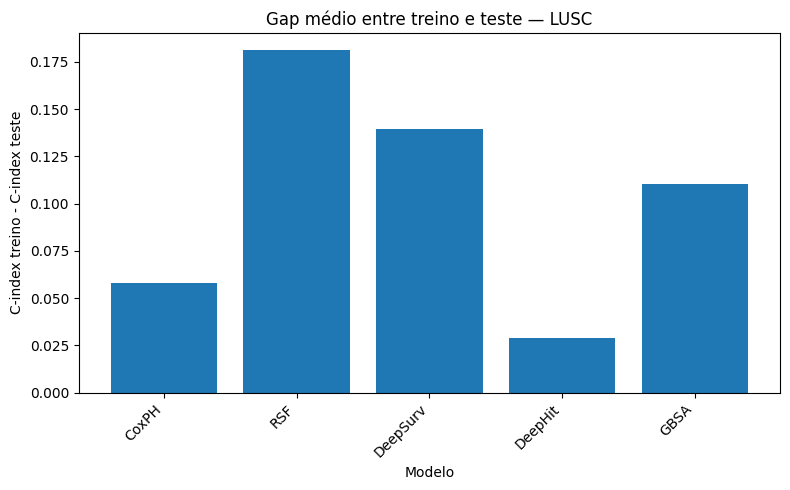

Figura salva: /workspaces/An-lise-de-Sobrevida/reports/figures/lusc/lusc_gap_modelos.png


In [35]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    tabela_tcc["modelo"],
    tabela_tcc["gap_medio"]
)

ax.set_title("Gap médio entre treino e teste — LUSC")
ax.set_xlabel("Modelo")
ax.set_ylabel("C-index treino - C-index teste")

plt.xticks(rotation=45, ha="right")

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "lusc_gap_modelos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura salva:", FIGURES_DIR / "lusc_gap_modelos.png")

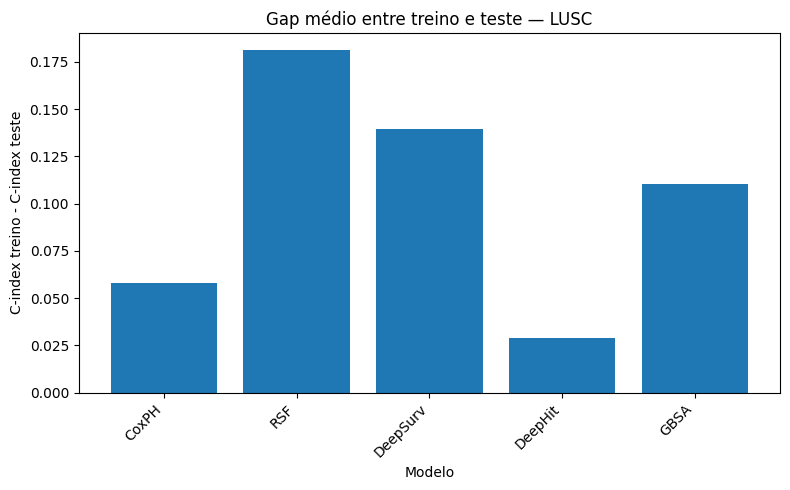

Figura salva: /workspaces/An-lise-de-Sobrevida/reports/figures/lusc/lusc_gap_modelos.png


In [36]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    tabela_tcc["modelo"],
    tabela_tcc["gap_medio"]
)

ax.set_title("Gap médio entre treino e teste — LUSC")
ax.set_xlabel("Modelo")
ax.set_ylabel("C-index treino - C-index teste")

plt.xticks(rotation=45, ha="right")

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "lusc_gap_modelos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura salva:", FIGURES_DIR / "lusc_gap_modelos.png")

In [37]:
hiperparametros = pd.DataFrame([
    {
        "modelo": "CoxPH",
        "configuracao": "penalizer=1.0; scaler=True; variance_threshold=0.01; corr_threshold=0.90"
    },
    {
        "modelo": "Weibull AFT",
        "configuracao": "penalizer=1.0; scaler=True; variance_threshold=0.01; corr_threshold=0.90"
    },
    {
        "modelo": "RSF",
        "configuracao": "n_estimators=200; min_samples_split=20; min_samples_leaf=15; max_features=sqrt; max_depth=10; corr_threshold=0.95"
    },
    {
        "modelo": "GBSA",
        "configuracao": "n_estimators=100; learning_rate=0.02; max_depth=1; subsample=0.7; corr_threshold=0.90"
    },
    {
        "modelo": "DeepSurv",
        "configuracao": "MLP=[32,16]; dropout=0.1; batch_size=32; epochs=100; lr=0.001; early_stopping=10"
    },
    {
        "modelo": "DeepHit",
        "configuracao": "MLP=[32,16]; num_durations=30; alpha=0.5; sigma=0.1; batch_size=32; epochs=200; lr=0.001; early_stopping=10"
    },
])

display(hiperparametros)

hiperparametros.to_csv(
    RESULTS_DIR / "lusc_hiperparametros.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

,modelo,configuracao
0,CoxPH,penalizer=1.0; scaler=True; variance_threshold...
1,Weibull AFT,penalizer=1.0; scaler=True; variance_threshold...
2,RSF,n_estimators=200; min_samples_split=20; min_sa...
3,GBSA,n_estimators=100; learning_rate=0.02; max_dept...
4,DeepSurv,"MLP=[32,16]; dropout=0.1; batch_size=32; epoch..."
5,DeepHit,"MLP=[32,16]; num_durations=30; alpha=0.5; sigm..."


In [ ]:
print("CHECKLIST FINAL — MODELOS LUSC")

print("Base usada:", DATA_PATH)
print("Shape final:", df.shape)
print("Quantidade de features:", X.shape[1])
print("Quantidade de pacientes:", X.shape[0])
print("Eventos:", int(evento.sum()))
print("Taxa de eventos:", round(evento.mean() * 100, 2), "%")

print("\nResultados gerados:")
for arquivo in sorted(RESULTS_DIR.glob("*.csv")):
    print("-", arquivo.name)

print("\nFiguras geradas:")
for figura in sorted(FIGURES_DIR.glob("*.png")):
    print("-", figura.name)

CHECKLIST FINAL — MODELOS LUSC
------------------------------------------------------------
Base usada: /workspaces/An-lise-de-Sobrevida/data/processed/lusc/lusc_modeling_dataset.csv
Shape final: (494, 60)
Quantidade de features: 58
Quantidade de pacientes: 494
Eventos: 212
Taxa de eventos: 42.91 %

Resultados gerados:
- lusc_hiperparametros.csv
- lusc_resultados_por_fold.csv
- lusc_resumo_modelos.csv

Figuras geradas:
- lusc_clinical_profile.png
- lusc_gap_modelos.png
- lusc_kaplan_meier.png
